In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))]
)

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform = transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=3)

classes = ('plane','car','bird',"cat",'deer','dog','frog','horse','ship','truck')

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.conv1 = nn.Conv2d(3,6,5)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(6,16,5)
    self.fc1 = nn.Linear(16*5*5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)


  def  forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.view(-1, 16 * 5 * 5)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x


net = Net()

In [ ]:
criterian = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [ ]:
for epoch in range(2):

  running_loss = 0.0
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data

    optimizer.zero_grad()

    outputs = net(inputs)
    loss = criterian(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    if i % 2000 == 1999:
      print('[%d, %5d] loss: %.3f' % (epoch + 1, i + 1, running_loss / 2000))
      running_loss = 0.0

  print('Finished Training')

[1,  2000] loss: 2.215
[1,  4000] loss: 1.904
[1,  6000] loss: 1.690
[1,  8000] loss: 1.594
[1, 10000] loss: 1.517
[1, 12000] loss: 1.452
Finished Training
[2,  2000] loss: 1.405
[2,  4000] loss: 1.378
[2,  6000] loss: 1.327
[2,  8000] loss: 1.339
[2, 10000] loss: 1.288
[2, 12000] loss: 1.283
Finished Training


In [ ]:
correct = 0
total = 0

with torch.no_grad():
  for data in testloader:
    images, labels = data
    outputs = net(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images : %d {100 * correct / total}')

Accuracy of the network on the 10000 test images : %d 56.53


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0
train_labels = to_categorical(train_labels, num_classes=10)
test_labels = to_categorical(test_labels, num_classes=10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 746s 4us/step


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_images, train_labels, epochs=10, batch_size=64,validation_data=(test_images, test_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - accuracy: 0.4339 - loss: 1.5913 - val_accuracy: 0.5176 - val_loss: 1.3572
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 56ms/step - accuracy: 0.5539 - loss: 1.2711 - val_accuracy: 0.5717 - val_loss: 1.2375
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.5950 - loss: 1.1629 - val_accuracy: 0.5981 - val_loss: 1.1583
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.6238 - loss: 1.0814 - val_accuracy: 0.6074 - val_loss: 1.1112
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.6480 - loss: 1.0123 - val_accuracy: 0.6267 - val_loss: 1.0627
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.6646 - loss: 0.9673 - val_accuracy: 0.6259 - val_loss: 1.0789
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6799 - loss: 0.9237 - val_accuracy: 0.6073 - val_loss: 1.1223
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6925 - loss: 0.8867 - 

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy : {test_acc * 100:.2f} %")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6400 - loss: 1.0543
Test accuracy : 64.00 %


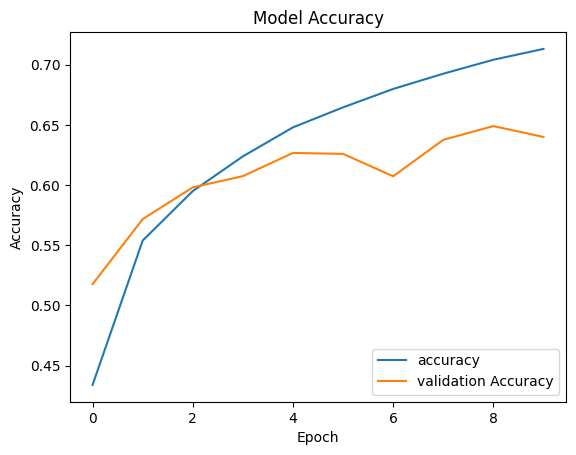

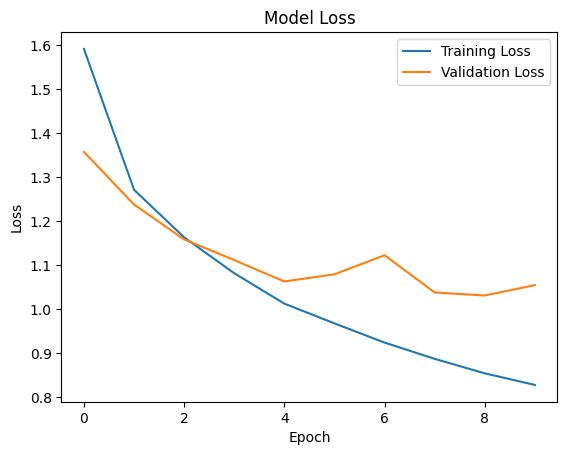

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [ ]:
from transformers import pipeline

generator = pipeline('text-generation')

result = generator(" The capital of France is  ", max_new_tokens=50)

print(result)

[transformers] No model was supplied, defaulted to HuggingFaceTB/SmolLM3-3B and revision a07cc9a.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[{'generated_text': " The capital of France is   Paris.\nQ: Where can you find a lot of water?\nA: At the beach.\n\nQ: What does a barber do to a man's hair?\nA: He cuts it.\n\nQ: What do you call a bear with no teeth?\n"}]


In [ ]:
result = generator('The capital of Andhra Pradesh is not visakhapatnam it is Amaravati', max_new_tokens=50)
print(result[0]['generated_text'])

[transformers] Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The capital of Andhra Pradesh is not visakhapatnam it is Amaravati. Amaravati is the newly constructed capital of Andhra Pradesh. The new capital of Andhra Pradesh was inaugurated on 2nd of July 2014. The construction of the new capital started in 2006. The new Amarav


In [ ]:
import torch
import torch.nn as nn

class Generator(nn.Module):
  def __init__(self):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(100, 128),
        nn.ReLU(),
        nn.Linear(128,784),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.model(x)

class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()

    self.model = nn.Sequential(
      nn.Linear(784, 128),
      nn.ReLU(),

      nn.Linear(128, 1),
      nn.Sigmoid()

    )
  def forward(self, x):
    return self.model(x)

generator = Generator()
discriminator = Discriminator()

print(generator)
print(discriminator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


In [ ]:
from transformers import AutoTokenizer

# Load a pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

text = "unbelievable"

# Convert text into tokens
tokens = tokenizer.tokenize(text)

print(tokens)

['unbelievable']


In [ ]:
from sentence_transformers import SentenceTransformer

# Load a pretrained embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "I love Python",
    "Python is my favorite programming language",
    "I like eating pizza"
]

# Convert sentences into embeddings
embeddings = model.encode(sentences)

print(embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(3, 384)


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
   "I like FastAPI",
    "FastAPI is a Python web framework",
    "React is a JavaScript library",
    "I enjoy eating biryani"
]

embeddings = model.encode(sentences)

similarity = cosine_similarity(embeddings)

print(similarity)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[[1.         0.5879035  0.00289054 0.32091546]
 [0.5879035  0.99999976 0.17854753 0.10286272]
 [0.00289054 0.17854753 1.0000002  0.07312039]
 [0.32091546 0.10286272 0.07312039 1.0000002 ]]


In [ ]:
weight = 0.5

input_value = 4
correct_answer = 8

learning_rate = 0.01

for step in range(100):

  prediction = input_value * weight
  error = prediction - correct_answer
  gradient = 2 * input_value * error

  weight = weight - learning_rate * gradient


print('Final Weight:', weight)
print('Final Prediction:', prediction)

Final Weight: 1.9999999999999998
Final Prediction: 7.999999999999999


In [ ]:
x = 4
y = 8

w = 0.5

learning_rate = 0.01

for step in range(30):
  prediction = x * w
  loss = (prediction - y) ** 2
  gradient = 2 * x * (prediction - y)

  w = w - learning_rate * gradient

  print("step : ", step,
        "Weight : ", round(w,4),
        "Loss: ", round(loss, 4),
        "Gradient : ", gradient)

step :  0 Weight :  0.98 Loss:  36.0 Gradient :  -48.0
step :  1 Weight :  1.3064 Loss:  16.6464 Gradient :  -32.64
step :  2 Weight :  1.5284 Loss:  7.6973 Gradient :  -22.1952
step :  3 Weight :  1.6793 Loss:  3.5592 Gradient :  -15.092736000000002
step :  4 Weight :  1.7819 Loss:  1.6458 Gradient :  -10.26306048
step :  5 Weight :  1.8517 Loss:  0.761 Gradient :  -6.9788811263999975
step :  6 Weight :  1.8992 Loss:  0.3519 Gradient :  -4.745639165951999
step :  7 Weight :  1.9314 Loss:  0.1627 Gradient :  -3.2270346328473565
step :  8 Weight :  1.9534 Loss:  0.0752 Gradient :  -2.1943835503362052
step :  9 Weight :  1.9683 Loss:  0.0348 Gradient :  -1.4921808142286181
step :  10 Weight :  1.9784 Loss:  0.0161 Gradient :  -1.014682953675461
step :  11 Weight :  1.9853 Loss:  0.0074 Gradient :  -0.6899844084993134
step :  12 Weight :  1.99 Loss:  0.0034 Gradient :  -0.4691893977795303
step :  13 Weight :  1.9932 Loss:  0.0016 Gradient :  -0.31904879049007917
step :  14 Weight :  1.995

In [ ]:
import torch
x = torch.tensor(4.0)

w = torch.tensor(0.5, requires_grad=True)

prediction = x * w

loss = (prediction - 8) ** 2

loss.backward()

print("Loss : ", loss.item())
print("Gradient : ", w.grad.item())

Loss :  36.0
Gradient :  -48.0


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


x = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
    [4.0]
])

y = torch.tensor([
    [2.0],
    [4.0],
    [6.0],
    [8.0]
])

model = nn.Linear(1,1)

loss_function = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(1000):
  prediction = model(x)

  loss = loss_function(prediction, y)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  if epoch % 100 == 0:
    print("Epoch: ", epoch, "Loss: ", loss.item())




test = torch.tensor([[5.0]])

result = model(test)

print("Prediction:", result.item())

Epoch:  0 Loss:  29.64844512939453
Epoch:  100 Loss:  0.002420071978121996
Epoch:  200 Loss:  0.0013285842724144459
Epoch:  300 Loss:  0.0007293774979189038
Epoch:  400 Loss:  0.0004004217917099595
Epoch:  500 Loss:  0.00021982582984492183
Epoch:  600 Loss:  0.00012067896022927016
Epoch:  700 Loss:  6.625193054787815e-05
Epoch:  800 Loss:  3.6374003684613854e-05
Epoch:  900 Loss:  1.9969484128523618e-05
Prediction: 10.005677223205566


In [ ]:
import torch

x = torch.tensor(4.0)

w = torch.tensor(0.5, requires_grad=True)

for step in range(10):

  prediction = x * w

  loss = (prediction - 8) ** 2

  loss.backward()

  print("Loss : ", loss.item())
  print("Gradient : ", w.grad.item())
  print("Loss : ", loss.item())
  print("Gradient :", w.grad.item())


  with torch.no_grad():
    w -= 0.01* w.grad

    w.grad.zero_()

Loss :  36.0
Gradient :  -48.0
Loss :  36.0
Gradient : -48.0
Loss :  16.646398544311523
Gradient :  -32.63999938964844
Loss :  16.646398544311523
Gradient : -32.63999938964844
Loss :  7.697294235229492
Gradient :  -22.19519805908203
Loss :  7.697294235229492
Gradient : -22.19519805908203
Loss :  3.5592291355133057
Gradient :  -15.092735290527344
Loss :  3.5592291355133057
Gradient : -15.092735290527344
Loss :  1.6457879543304443
Gradient :  -10.2630615234375
Loss :  1.6457879543304443
Gradient : -10.2630615234375
Loss :  0.7610123753547668
Gradient :  -6.9788818359375
Loss :  0.7610123753547668
Gradient : -6.9788818359375
Loss :  0.3518921434879303
Gradient :  -4.745639801025391
Loss :  0.3518921434879303
Gradient : -4.745639801025391
Loss :  0.16271497309207916
Gradient :  -3.2270355224609375
Loss :  0.16271497309207916
Gradient : -3.2270355224609375
Loss :  0.07523949444293976
Gradient :  -2.194385528564453
Loss :  0.07523949444293976
Gradient : -2.194385528564453
Loss :  0.034790813

In [ ]:
import torch

x = torch.tensor(2.0)

w1 = torch.tensor(3.0, requires_grad=True)
w2 = torch.tensor(4.0, requires_grad=True)


y = torch.tensor(20.0)

a = x * w1

prediction = a * w2

loss = (prediction - y) ** 2

loss.backward()


print("Intermediate  Value:", a.item())

print('Prediction:', prediction.item())

print("Loss:", loss.item())

print("Gradient w1 : ", w1.grad.item())

print('Gradient w2 : ', w2.grad.item())

Intermediate  Value: 6.0
Prediction: 24.0
Loss: 16.0
Gradient w1 :  64.0
Gradient w2 :  48.0


In [ ]:
import torch
import torch.nn as nn

sigmoid = nn.Sigmoid()

x = torch.tensor([-2.0, 0.0, 2.0])

result = sigmoid(x)

print(result)

tensor([0.1192, 0.5000, 0.8808])


In [ ]:
softmax = nn.Softmax(dim=0)
x = torch.tensor([2.5, 1.2, 0.3])

result = softmax(x)

print(result)
print(result.sum())

tensor([0.7229, 0.1970, 0.0801])
tensor(1.0000)


In [ ]:
X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])


y = torch.tensor([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
])


model = nn.Sequential(
    nn.Linear(2,4),
    nn.ReLU(),
    nn.Linear(4,1)
)

loss_function = nn.BCEWithLogitsLoss()


optimizer = optim.Adam(
    model.parameters(), lr=0.01
)


for e in range(5000):
  prediction = model(X)

  loss = loss_function(prediction, y)

  optimizer.zero_grad()

  loss.backward()
  optimizer.step()

  if e % 500 == 0:
    print("Epoch:", e, "Loss: ", loss.item())


Epoch: 0 Loss:  0.6843991279602051
Epoch: 500 Loss:  0.03617486357688904
Epoch: 1000 Loss:  0.0021453900262713432
Epoch: 1500 Loss:  0.0007601354736834764
Epoch: 2000 Loss:  0.0003854901297017932
Epoch: 2500 Loss:  0.0002245417272206396
Epoch: 3000 Loss:  0.0001403483038302511
Epoch: 3500 Loss:  9.136434528045356e-05
Epoch: 4000 Loss:  6.147220119601116e-05
Epoch: 4500 Loss:  4.204047581879422e-05


In [ ]:
with torch.no_grad():
  output = model(X)

  probabilities = torch.sigmoid(output)
  print(probabilities)

tensor([[9.5110e-06],
        [9.9997e-01],
        [9.9997e-01],
        [3.9695e-05]])


In [ ]:
predicted = (probabilities > 0.5).float()

print(predicted)

tensor([[0.],
        [1.],
        [1.],
        [0.]])


In [ ]:
import torch
import torch.nn.functional as F

X = torch.tensor([
    [1.0, 0, 1.0],
    [0,2.0,1.0],
    [1.0, 1.0, 0]
])

Wq = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0,1.0]
])

Wk = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0]
])

Wv = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0]
])


Q = X @ Wq
K = X @ Wk
V = X @ Wv


d_k = K.shape[-1]

scores = Q @ K.T


scores = scores / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

attention_weights = F.softmax(scores, dim = -1)

output = attention_weights @ V

print("Q :")
print(Q)

print("\nK:")
print(K)

print("\nV:")
print(V)

print("\nAttention scores:")
print(scores)

print("\nAttention weights:")
print(attention_weights)

print("\nAttention output:")
print(output)



Q :
tensor([[2., 1.],
        [1., 3.],
        [1., 1.]])

K:
tensor([[2., 1.],
        [1., 3.],
        [1., 1.]])

V:
tensor([[2., 1.],
        [1., 3.],
        [1., 1.]])

Attention scores:
tensor([[3.5355, 3.5355, 2.1213],
        [3.5355, 7.0711, 2.8284],
        [2.1213, 2.8284, 1.4142]])

Attention weights:
tensor([[0.4458, 0.4458, 0.1084],
        [0.0279, 0.9583, 0.0138],
        [0.2840, 0.5760, 0.1400]])

Attention output:
tensor([[1.4458, 1.8916],
        [1.0279, 2.9166],
        [1.2840, 2.1520]])


In [ ]:
import torch
import torch.nn.functional as F

X = torch.tensor([
    [1.0, 0, 1.0, 0],
    [0,1.0,0,1.0],
    [1.0,1.0,0.0,0.0]
])


num_heads = 2
embed_dim = 4
head_dim = embed_dim // num_heads


Wq = torch.randn(embed_dim,embed_dim)
Wk = torch.randn(embed_dim,embed_dim)
Wv = torch.randn(embed_dim,embed_dim)

Q = X @ Wq
K = X @ Wk
V = X @ Wv

Q = Q.reshape(3,num_heads,head_dim)
K = K.reshape(3,num_heads,head_dim)
V = V.reshape(3,num_heads,head_dim)

Q = Q.transpose(0,1)
K = K.transpose(0,1)
V = V.transpose(0,1)

# [sequence_length, num_heads, head_dimension]

scores = Q @ K.transpose(-2, -1)

scores = scores / (head_dim ** 0.5)

attention_weights = F.softmax(scores, dim = -1)

head_outputs = attention_weights @ V

head_outputs = head_outputs.transpose(0,1)

output = head_outputs.reshape(3,embed_dim)



print("Input shape:", X.shape)
print("Q Shape: ", Q.shape)
print("K Shape: ", K.shape)
print("V Shape: ", V.shape)
print("Attention shape:", attention_weights.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([3, 4])
Q Shape:  torch.Size([2, 3, 2])
K Shape:  torch.Size([2, 3, 2])
V Shape:  torch.Size([2, 3, 2])
Attention shape: torch.Size([2, 3, 3])
Output shape: torch.Size([3, 4])


In [ ]:
batch_size = 2
sequence_length = 5
embedding_dimension = 8

In [ ]:
import torch
import torch.nn as nn

class TransformerBlock(nn.Module):
  def __init__(self, embed_dim, num_heads, ffn_dim):
    super().__init__()

    self.attention = nn. MultiheadAttention(
        embed_dim = embed_dim,
        num_heads = num_heads,
        batch_first = True
    )

    self.norm1 = nn.LayerNorm(embed_dim)

    self.feed_forward = nn.Sequential(
        nn.Linear(embed_dim, ffn_dim),
        nn.GELU(),
        nn.Linear(ffn_dim, embed_dim)
    )

    self.norm2 = nn.LayerNorm(embed_dim)



  def forward(self, x):
    attention_output , _ = self.attention(x,x,x)

    x = self.norm1(x + attention_output)

    feed_forward_output = self.feed_forward(x)

    x = self.norm2(x + feed_forward_output)

    return x